In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving occupancy.xlsx to occupancy.xlsx


In [3]:
occ_df = pd.read_excel("occupancy.xlsx")


In [4]:
occ_df.head()

,Period,occupancy
0,1,1861
1,2,2203
2,3,2415
3,4,1908
4,5,1921


#checking white noise
ACF - All spikes (except lag 0) are within the confidence interval.

No systematic pattern.If most lags lie inside the blue confidence band, the series behaves like white noise.


In [6]:
from statsmodels.stats.diagnostic import acorr_ljungbox


In [7]:

acorr_ljungbox(occ_df.occupancy, lags=[9], return_df=True)


,lb_stat,lb_pvalue
9,33.239318,0.000121


H₀ (Null Hypothesis): Data is white noise (no autocorrelation).

H₁ (Alternative Hypothesis): Data has autocorrelation.
Decision Rule

If p-value > 0.05 → Fail to reject H₀ → Series is white noise

If p-value < 0.05 → Reject H₀ → Series is not white noise
p-value = 0.000121

0.000121 < 0.05
The series is not white noise.
There is significant autocorrelation present up to lag 9, meaning the observations are not independent.
the series exhibits significant autocorrelation and is not white noise.
Original data	Should NOT be white noise
Model residuals	Should be white noise

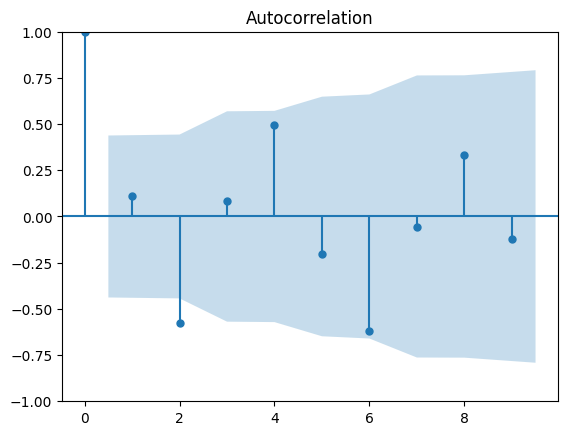

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Show autocorrelation upto lag 20
acf_plot = plot_acf( occ_df.occupancy,lags=9)

The ACF plot shows how the time series correlates with its past values (lags). The blue shaded region represents the 95% confidence interval. Any spike outside this region is statistically significant.
The series does not show a smooth exponential decay, so it is not a clear AR process.
Significant spikes at lag 2 and lag 6 indicate cyclical behavior or periodicity.
The pattern suggests the data might contain seasonality or oscillation every 4–6 periods
Might suit MA or seasonal ARIMA


the shaded area represents the upper and lower bounds for critical values, where the null
hypothesis cannot be rejected (auto-correlation value is 0). So, as can be seen from figure, null
hypothesis is rejected only for lag = 1 (i e., auto-correlation is statistically significant for lag 1).

In [9]:
occ_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Period     20 non-null     int64
 1   occupancy  20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes


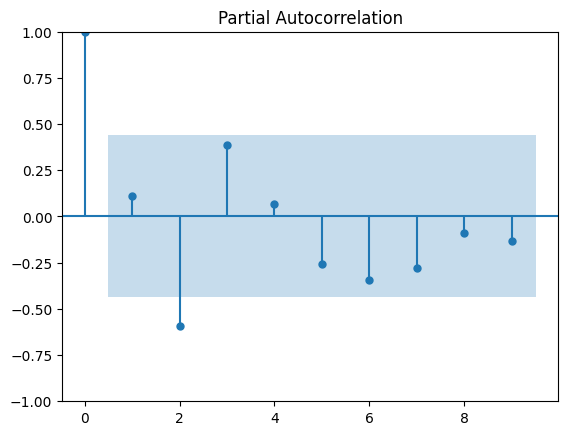

In [10]:
pacf_plot = plot_pacf( occ_df.occupancy,lags=9)

The PACF shows several significant spikes rather than a sharp cutoff.

This suggests the series may not be a simple AR(p) process.

The strong spikes at lag 1 and lag 2 indicate short-term autoregressive influence.

Large spikes at lag 8–9 may indicate longer cycle or seasonal effects.


the shaded area represents the upper and lower bounds for critical values, where the null
hypothesis cannot be rejected. So, for lag = 1 the partial auto-correlation is significant.

# AR(p)  model

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

In [14]:
from google.colab import files
uploaded = files.upload()

Saving occupancy_d.xlsx to occupancy_d.xlsx


In [16]:
#occ_df1 =pd.read_excel("occupancy_d.xlsx")

occ_df1 =pd.read_excel("occupancy_d.xlsx")

In [17]:
occ_df1.head()

,date,occupancy
0,1991-01-01,1861
1,1991-04-01,2203
2,1991-07-01,2415
3,1991-10-01,1908
4,1992-01-01,1921


In [18]:
occ_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       20 non-null     datetime64[ns]
 1   occupancy  20 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 452.0 bytes


In [19]:
# Select first 20 observations
y = occ_df1['occupancy'].iloc[0:19].astype(int)

In [24]:
# Fit ARIMA model
arima1 = ARIMA(y, order=(1,0,0))
ar1_model = arima1.fit()

In [25]:
# Print summary
print(ar1_model.summary())

                               SARIMAX Results                                
Dep. Variable:              occupancy   No. Observations:                   19
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -129.376
Date:                Sun, 03 May 2026   AIC                            264.753
Time:                        19:38:45   BIC                            267.586
Sample:                             0   HQIC                           265.232
                                 - 19                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2104.8611     61.876     34.017      0.000    1983.586    2226.136
ar.L1          0.1540      0.269      0.573      0.567      -0.373       0.681
sigma2      4.802e+04    3.1e+04      1.548      0.1

from previous PACF plot we could seea significant value at lag 2 . an Ar (2) model xcould provide better forecast tghan AR (1) model

# AR 2 model
An AR(2) model is a time series model where the current value depends on the previous two time periods.
PACF plot cuts off after lag 2 (significant spikes at lag 1 and 2).ACF plot gradually tails off instead of cutting sharply.

In [26]:
ar2 = ARIMA(y, order=(2,0,0))
ar2_fit = ar2.fit()
print(ar2_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              occupancy   No. Observations:                   19
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -124.796
Date:                Sun, 03 May 2026   AIC                            257.591
Time:                        19:40:40   BIC                            261.369
Sample:                             0   HQIC                           258.230
                                 - 19                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2094.3786     34.725     60.314      0.000    2026.319    2162.438
ar.L1          0.2286      0.211      1.083      0.279      -0.185       0.642
ar.L2         -0.6538      0.286     -2.283      0.0

In [27]:
residuals = ar2_fit.resid

In [28]:
from statsmodels.stats.diagnostic import acorr_ljungbox

#lb_test = acorr_ljungbox(residuals, lags=[9], return_df=True)

lb_test = acorr_ljungbox(residuals,lags=[9],return_df= True)
print(lb_test)

     lb_stat  lb_pvalue
9  15.345341   0.081876


#> 0.05	Residuals are white noise → AR(2) model is adequate
#< 0.05	Residuals are not white noise → model may be inadequate

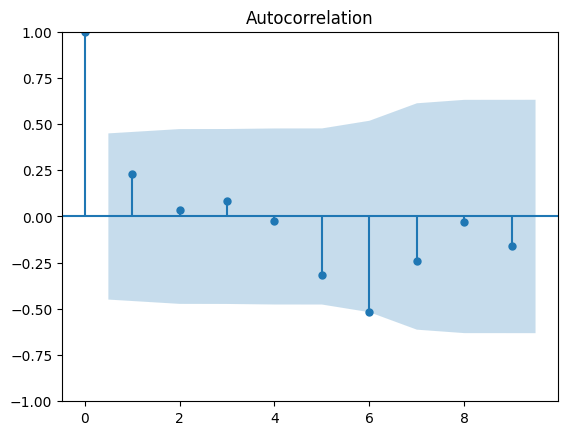

In [29]:
plot_acf(residuals)
plt.show()

# MA(q)

In [31]:
modelma = ARIMA(y, order=(0,0,1))
modelma_fit = modelma.fit()
residualsma1 = modelma_fit.resid

In [32]:
lb_ma1 = acorr_ljungbox(residualsma1,lags=[9],return_df= True)
print(lb_ma1)

     lb_stat  lb_pvalue
9  22.650049   0.007032


ma1 process is not a reliable method for forecasting for the current data as the residuals are not white noise. - p<alpha

We reject null and conclude that residuals are not white noise
                        from AR results we can see than p>alpha
    this indicates that auto regression is a superior method for
    forecasting for current data

In [34]:
#MA(1)

modelma = ARIMA(y, order=(0,0,1))   # MA(1)
modelma_fit = modelma.fit()
print(modelma_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              occupancy   No. Observations:                   19
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -127.238
Date:                Sun, 03 May 2026   AIC                            260.476
Time:                        19:44:25   BIC                            263.309
Sample:                             0   HQIC                           260.955
                                 - 19                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2103.5973     83.208     25.281      0.000    1940.512    2266.682
ma.L1          0.6910      0.235      2.936      0.003       0.230       1.152
sigma2       3.71e+04   2.29e+04      1.618      0.1

In [35]:
#MA(2)

modelma2 = ARIMA(y, order=(0,0,2))   # MA(2)
modelma2_fit = modelma2.fit()
print(modelma2_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              occupancy   No. Observations:                   19
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -126.217
Date:                Sun, 03 May 2026   AIC                            260.434
Time:                        19:44:39   BIC                            264.212
Sample:                             0   HQIC                           261.074
                                 - 19                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2100.6777     38.725     54.247      0.000    2024.779    2176.577
ma.L1          0.2787      0.302      0.923      0.356      -0.313       0.871
ma.L2         -0.4189      0.292     -1.435      0.1

# ARMA

In [36]:
# Step 1: Select the  time series column
data = occ_df1['occupancy'].astype(float)

In [37]:
# Step 2: Fit ARMA(p,q) model
# Example: ARMA(2,0,2) → change (p,0,q) based on your ACF/PACF
arma = ARIMA(data, order=(1,0,1))
arma_fit = arma.fit()
print(arma_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              occupancy   No. Observations:                   20
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -133.681
Date:                Sun, 03 May 2026   AIC                            275.361
Time:                        19:45:14   BIC                            279.344
Sample:                             0   HQIC                           276.139
                                 - 20                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2091.0088     72.024     29.032      0.000    1949.844    2232.173
ar.L1         -0.2042      0.425     -0.480      0.631      -1.037       0.629
ma.L1          0.7379      0.336      2.197      0.0

In [38]:
# Step 3: Extract residuals
residualsarma = arma_fit.resid

In [39]:
lb_arma_test = acorr_ljungbox(residuals, lags=[10], return_df=True)

In [40]:
lb_arma_test

,lb_stat,lb_pvalue
10,15.385569,0.118624


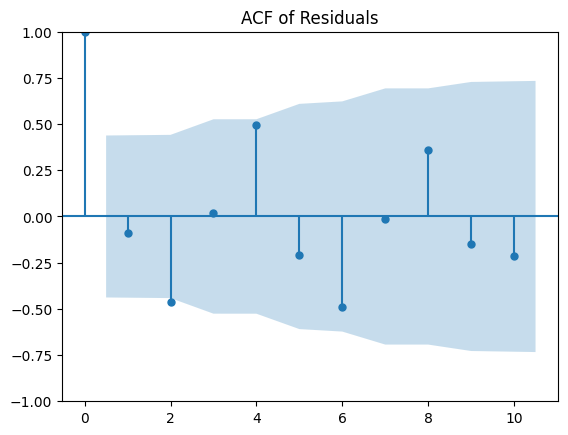

In [41]:
plot_acf(residualsarma)
plt.title("ACF of Residuals")
plt.show()

In [42]:
arma2 = ARIMA(data, order=(2,0,2))
arma2_fit = arma2.fit()

print(arma2_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              occupancy   No. Observations:                   20
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -125.926
Date:                Sun, 03 May 2026   AIC                            263.852
Time:                        19:45:58   BIC                            269.826
Sample:                             0   HQIC                           265.018
                                 - 20                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2098.0440     45.424     46.188      0.000    2009.014    2187.074
ar.L1         -0.0345      0.084     -0.409      0.683      -0.200       0.131
ar.L2         -0.9818      0.052    -19.061      0.0

In [43]:
residualsarma2 = arma2_fit.resid


In [44]:
lb_arma2_test = acorr_ljungbox(residualsarma2, lags=[10], return_df=True)

In [45]:
lb_arma2_test

,lb_stat,lb_pvalue
10,17.953306,0.055756


# ARIMA

In [46]:
data = occ_df1['occupancy'].astype(float)

In [47]:
arima= ARIMA(data, order=(2,1,2))
arima_fit = arima.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              occupancy   No. Observations:                   20
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -121.585
Date:                Sun, 03 May 2026   AIC                            253.170
Time:                        19:48:11   BIC                            257.892
Sample:                             0   HQIC                           253.969
                                 - 20                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0481      0.050     -0.957      0.339      -0.147       0.050
ar.L2         -0.9970      0.018    -54.351      0.000      -1.033      -0.961
ma.L1         -0.0342      0.257     -0.133      0.8

In [48]:
residualsarima = arima_fit.resid

In [49]:
lbarima_test = acorr_ljungbox(residualsarima, lags=[10], return_df=True)
print(lbarima_test)

     lb_stat  lb_pvalue
10  2.856514   0.984602


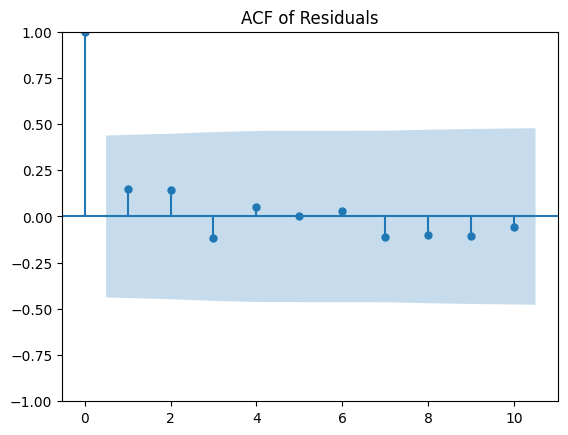

In [50]:
plot_acf(residualsarima)
plt.title("ACF of Residuals")
plt.show()

In [51]:
forecast_arima = arima_fit.forecast(steps=4)
print("Forecast:", forecast_arima)

Forecast: 20    1994.076310
21    2341.622588
22    2297.905214
23    1953.502323
Name: predicted_mean, dtype: float64


this seems to give best results compared to AR, MA, ARMA  models of p and q order
BIC least, p value highest of ljungbox, ACF plot shows more white noise of residuals compared to others

# SARIMA - seasonal with ARIMA
Non-seasonal → (p,d,q) = (1,1,1)
Seasonal → (P,D,Q,s) = (1,1,1,4)
note: quarterly data - s=4, monthly s=12, weekly s=7

In [52]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

In [53]:
data = occ_df1['occupancy'].astype(float)

In [54]:
sarima = SARIMAX(data,
                order=(1,1,1),
                seasonal_order=(1,1,1,4))

sarima_fit = sarima.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                         occupancy   No. Observations:                   20
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood                 -95.934
Date:                           Sun, 03 May 2026   AIC                            201.869
Time:                                   19:49:54   BIC                            205.409
Sample:                                        0   HQIC                           201.831
                                            - 20                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9997   1242.101      0.001      0.999   -2433.474    2435.474
ma.L1         -0.9998   1348.782     -0.001

In [55]:
residuals_sarima = sarima_fit.resid

In [56]:
lb_sarima = acorr_ljungbox(residuals_sarima, lags=[10], return_df=True)
print(lb_sarima)

     lb_stat  lb_pvalue
10  5.872389   0.825868


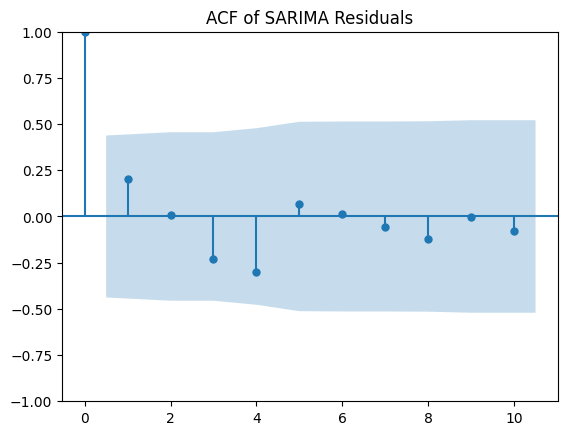

In [57]:
plot_acf(residuals_sarima)
plt.title("ACF of SARIMA Residuals")
plt.show()

In [58]:
forecast_sarima = sarima_fit.forecast(steps=4)
print("Forecast:", forecast_sarima)

Forecast: 20    1966.999061
21    2272.429151
22    2389.507019
23    1997.449636
Name: predicted_mean, dtype: float64
